In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from matplotlib.lines import Line2D

from matplotlib import rc
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

rc = {"font.family" : "serif", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
from matplotlib.ticker import MaxNLocator

# rc('text', usetex=False)

In [4]:
def get_all_accs(dataset, e0, budgets):
    accs = {}
    for ind in range(len(budgets)):
        accs[int(budgets[ind])] = []
        for priv_obl in [True, False]:
            res = []
            for tmp_ind in range(5):
                tmp = pickle.load(open(
                    f'composition_results/{dataset}_data_budget={int(budgets[ind])}_e0={e0}_aware={priv_obl}_{tmp_ind}.pkl', 'rb'))
                res.extend(tmp)
            accs[int(budgets[ind])].append(res)
        
    return accs


0.5531615120274914 100


(array([ 1.,  4.,  7., 14., 16., 14., 15., 16.,  5.,  8.]),
 array([0.18213058, 0.24801178, 0.31389298, 0.37977418, 0.44565538,
        0.51153657, 0.57741777, 0.64329897, 0.70918017, 0.77506136,
        0.84094256]),
 <BarContainer object of 10 artists>)

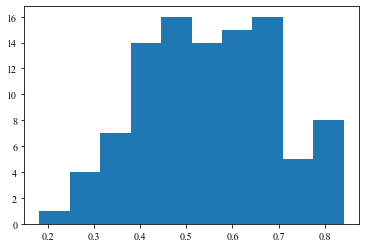

In [5]:
accs = get_all_accs('mnist_7_vs_9', 'exact', [1024])
ind = 1
tmp = [k[0] for k in accs[1024][ind]]
print(np.average(tmp), len(tmp))
plt.hist(tmp)

In [6]:
names = ['Credit', 'MNIST Binary (0 vs. 7)', 'MNIST Binary (7 vs. 9)']
for data_ind, data in enumerate(['credit', 'mnist_0_vs_7', 'mnist_7_vs_9']):
    mi_range = [2**(x) for x in range(-10, 0, 2)]
    e0 = 'exact'

    labels = [-np.log2(x) for x in mi_range]

    budget_range = [1/(mi) for mi in mi_range]
    budget_range.reverse()
    all_accs = get_all_accs(data, e0, budget_range)
    print(budget_range)
    
    for priv_ind, priv_obl in enumerate([True, False]):
        row_res = []
        row_res.append(f'& {priv_obl}')
        for budget in budget_range:
            accs = [k[0] for k in all_accs[budget][priv_ind]]
            mean = np.average(accs)
            fin = round(mean, 2)
            row_res.append(str(fin))
        print(' & '.join(row_res) + "\\\\ ")
        
    print('-------')
#     print(formatted)


[4.0, 16.0, 64.0, 256.0, 1024.0]
& True & 0.99 & 0.96 & 0.92 & 0.83 & 0.73\\ 
& False & 0.91 & 0.78 & 0.67 & 0.58 & 0.54\\ 
-------
[4.0, 16.0, 64.0, 256.0, 1024.0]
& True & 0.99 & 0.98 & 0.98 & 0.93 & 0.7\\ 
& False & 0.97 & 0.83 & 0.69 & 0.61 & 0.56\\ 
-------
[4.0, 16.0, 64.0, 256.0, 1024.0]
& True & 0.89 & 0.84 & 0.76 & 0.62 & 0.58\\ 
& False & 0.75 & 0.66 & 0.6 & 0.51 & 0.55\\ 
-------


100 100
100 100
100 100
100 100
100 100
[0.7718942173764105, 0.882298893129823, 0.9499997106244495, 0.9777403572419633, 0.9952001220901107]
100 100
100 100
100 100
100 100
100 100
[0.6983404313211169, 0.9318600908510272, 0.9871473246219443, 0.988572358696451, 0.9903425456634511]
100 100
100 100
100 100
100 100
100 100
[0.5841537981380421, 0.6374910401288713, 0.78657069030725, 0.8689807066715436, 0.9136990953390487]


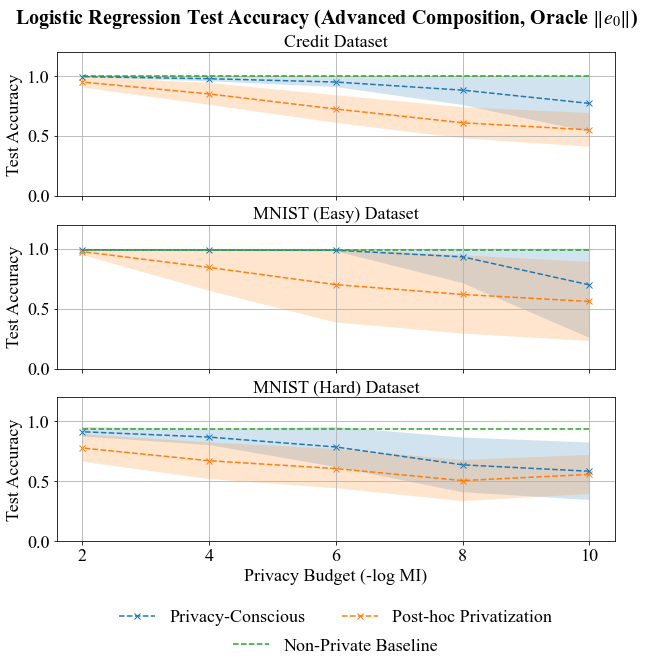

In [13]:
names = ['Credit', 'MNIST (Easy)', 'MNIST (Hard)']
global_handles, global_labels = [], []
baseline_handles, baseline_labels = [], []
fig, axes = plt.subplots(3, 1, figsize=(10,9), sharex=True)
baseline_vals = [1., 0.9905, 0.9332]

for data_ind, data in enumerate(['credit', 'mnist_0_vs_7', 'mnist_7_vs_9']):
    mi_range = [2**(x) for x in range(-10, -1, 2)]

    labels = [-np.log2(x) for x in mi_range]

    budget_range = [1/(mi) for mi in mi_range]
    ax = axes[data_ind]

    accs = get_all_accs(data, 'exact', budget_range)

    xs = []
    priv_aware = []
    priv_obl = []
    priv_aware_bands = []
    priv_obl_bands = []

    for i, c in enumerate(budget_range):
        print(len(accs[c][0]), len(accs[c][1]))
        xs.append(labels[i])
        
        aware_std = np.std(accs[c][0], ddof=1)
        aware_mean = np.average(accs[c][0])
        
        obl_std = np.std(accs[c][1], ddof=1)
        obl_mean = np.average(accs[c][1])
        

        priv_aware.append(aware_mean)
        priv_obl.append(obl_mean)
        priv_aware_bands.append((aware_mean-aware_std, aware_mean+aware_std))
        priv_obl_bands.append((obl_mean-obl_std, obl_mean+obl_std))

    aware_lower = [max(k[0], 0) for k in priv_aware_bands]
    aware_upper = [min(k[1], 1) for k in priv_aware_bands]
    obl_lower = [max(k[0], 0) for k in priv_obl_bands]
    obl_upper = [min(k[1], 1) for k in priv_obl_bands]
    where_mask = np.ones_like(xs, dtype=bool)

    line1 = ax.plot(xs, priv_aware, '--x', label='Privacy-Conscious')
    print(priv_aware)

    ax.fill_between(xs, aware_lower, aware_upper, where=where_mask, alpha=0.2, linewidth=0)
    
    line2 = ax.plot(xs, priv_obl, '--x', label='Post-hoc Privatization')
    ax.fill_between(xs, obl_lower, obl_upper, where=where_mask, alpha=0.2, linewidth=0)
    line3 = ax.plot(xs, [baseline_vals[data_ind]]*len(xs), '--', label = 'Non-Private Baseline')

    if data_ind == 0:
        for line in [line1, line2]:
            global_handles.append(line[0])
            global_labels.append(line[0].get_label())
        baseline_handles.append(line3[0])
        baseline_labels.append(line3[0].get_label())
    ax.grid(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f"{val:.1f}"))

    ax.tick_params(axis='both', labelsize=18)
    ax.set_title(f"{names[data_ind]} Dataset", fontsize=18, fontweight='normal')
    ax.set_ylabel("Test Accuracy", fontsize=18)
    ax.set_ylim((0, 1.2))
#     ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.minorticks_off()

ax.set_xlabel("Privacy Budget (-log MI)", fontsize=18)

# fig.subplots_adjust(bottom=0.18)

leg1=ax.legend(
    handles=global_handles,
    labels=global_labels,
    ncol = 2,
    bbox_to_anchor=(0.5, -0.7),
    loc='lower center',
    fontsize=18,
    frameon=False
)
ax.add_artist(leg1)

leg2 = ax.legend(
    handles=baseline_handles,
    labels=baseline_labels,
    ncol = 1,
    bbox_to_anchor=(0.5, -0.9),
    loc='lower center',
    fontsize=18,
    frameon=False
)
title = fig.suptitle(r"Logistic Regression Test Accuracy (Advanced Composition, Oracle $\Vert e_0 \Vert$)", fontsize=20, fontweight="bold", y=0.95)
fig.canvas.draw()
fig.savefig("../figs/gd_composition_accs.pdf", bbox_inches="tight", pad_inches=0.04)
